In [2]:
import sys
print(sys.executable)

/Users/ashmita/Downloads/project/Alexa_Sentiment_Analysis/venv/bin/python


In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, roc_curve)
 
sns.set_style('whitegrid')

In [13]:
%matplotlib inline

In [3]:
df = pd.read_csv('dataset.csv', skiprows=[1])

In [4]:
df.head()

,S. No.,Age,Sex,RBC,PCV,MCV,MCH,MCHC,RDW,TLC,PLT /mm3,HGB
0,1.0,28.0,0.0,5.66,34.0,60.1,17.0,28.2,20.0,11.10,128.3,9.6
1,2.0,41.0,0.0,4.78,44.5,93.1,28.9,31.0,13.0,7.02,419.0,13.8
2,3.0,40.0,1.0,4.65,41.6,89.5,28.8,32.2,13.0,8.09,325.0,13.4
3,4.0,76.0,0.0,4.24,36.7,86.6,26.7,30.8,14.9,13.41,264.0,11.3
4,5.0,20.0,1.0,4.14,36.9,89.1,27.8,31.2,13.2,4.75,196.0,11.5


In [5]:
df.columns = [c.strip() for c in df.columns]

In [6]:
df = df.drop(columns=['S. No.'])

In [7]:
df = df.dropna().reset_index(drop=True)

In [8]:
print("Shape after dropna:", df.shape)

Shape after dropna: (364, 11)


In [9]:
def label_anaemia(row):
    if row['Sex'] == 1:  # assume 1=Male
        return 1 if row['HGB'] < 13 else 0
    else:  # 0=Female
        return 1 if row['HGB'] < 12 else 0
 
df['Anaemia'] = df.apply(label_anaemia, axis=1)
print(df['Anaemia'].value_counts())

Anaemia
1    198
0    166
Name: count, dtype: int64


In [10]:
print(df.describe())

              Age         Sex         RBC         PCV         MCV         MCH  \
count  364.000000  364.000000  364.000000  364.000000  364.000000  364.000000   
mean    44.917582    0.442308    4.278736   36.762912   87.509121   28.227143   
std     18.780854    0.497344    0.820166    6.830835    9.332164    3.865998   
min     11.000000    0.000000    1.360000   13.100000   55.700000   14.700000   
25%     28.000000    0.000000    3.780000   32.900000   83.175000   26.300000   
50%     44.500000    0.000000    4.335000   36.800000   87.950000   28.200000   
75%     60.000000    1.000000    4.800000   41.850000   91.875000   30.400000   
max     89.000000    1.000000    6.900000   56.900000  124.100000   41.400000   

             MCHC         RDW         TLC    PLT /mm3         HGB     Anaemia  
count  364.000000  364.000000  364.000000  364.000000  364.000000  364.000000  
mean    32.053407   15.116511    8.863571  223.750824   11.907692    0.543956  
std      2.801790    2.176557 

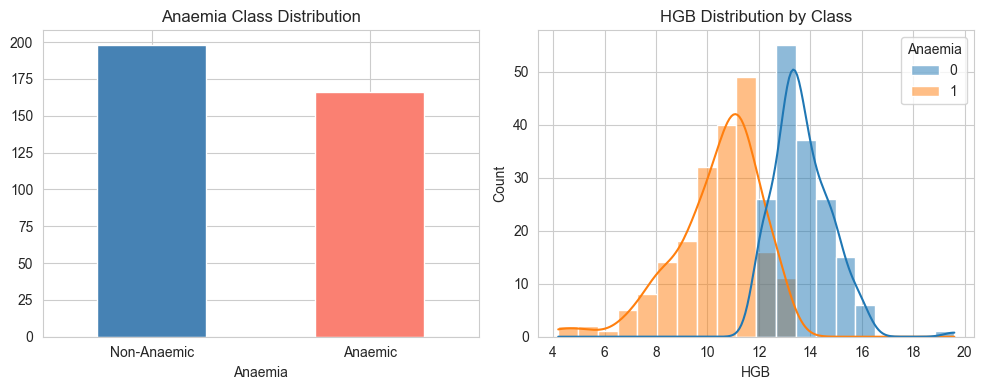

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['Anaemia'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'salmon']
)
axes[0].set_title('Anaemia Class Distribution')
axes[0].set_xticklabels(['Non-Anaemic', 'Anaemic'], rotation=0)

sns.histplot(
    data=df,
    x='HGB',
    hue='Anaemia',
    kde=True,
    ax=axes[1]
)
axes[1].set_title('HGB Distribution by Class')

plt.tight_layout()
plt.show()
plt.close()    

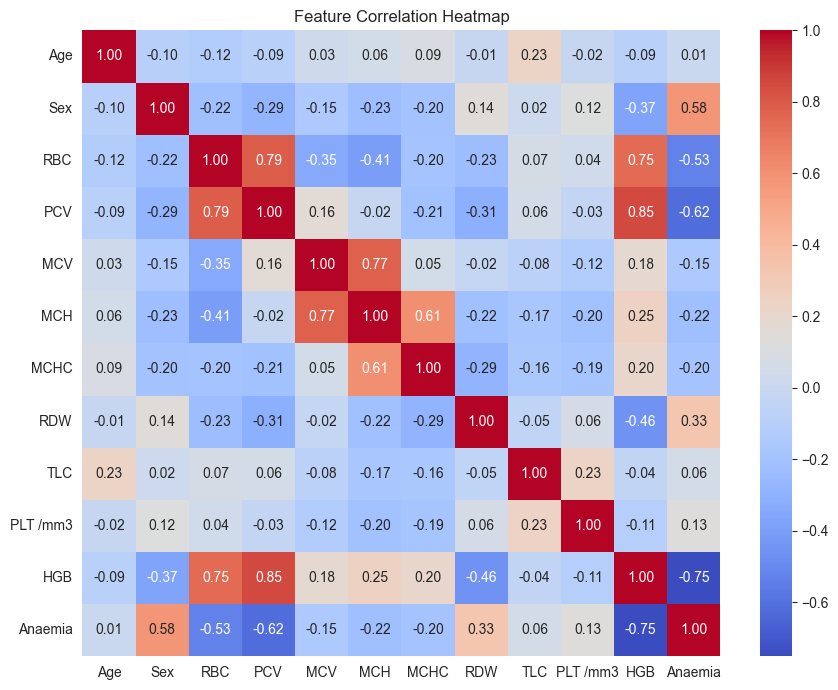

In [16]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
plt.close()

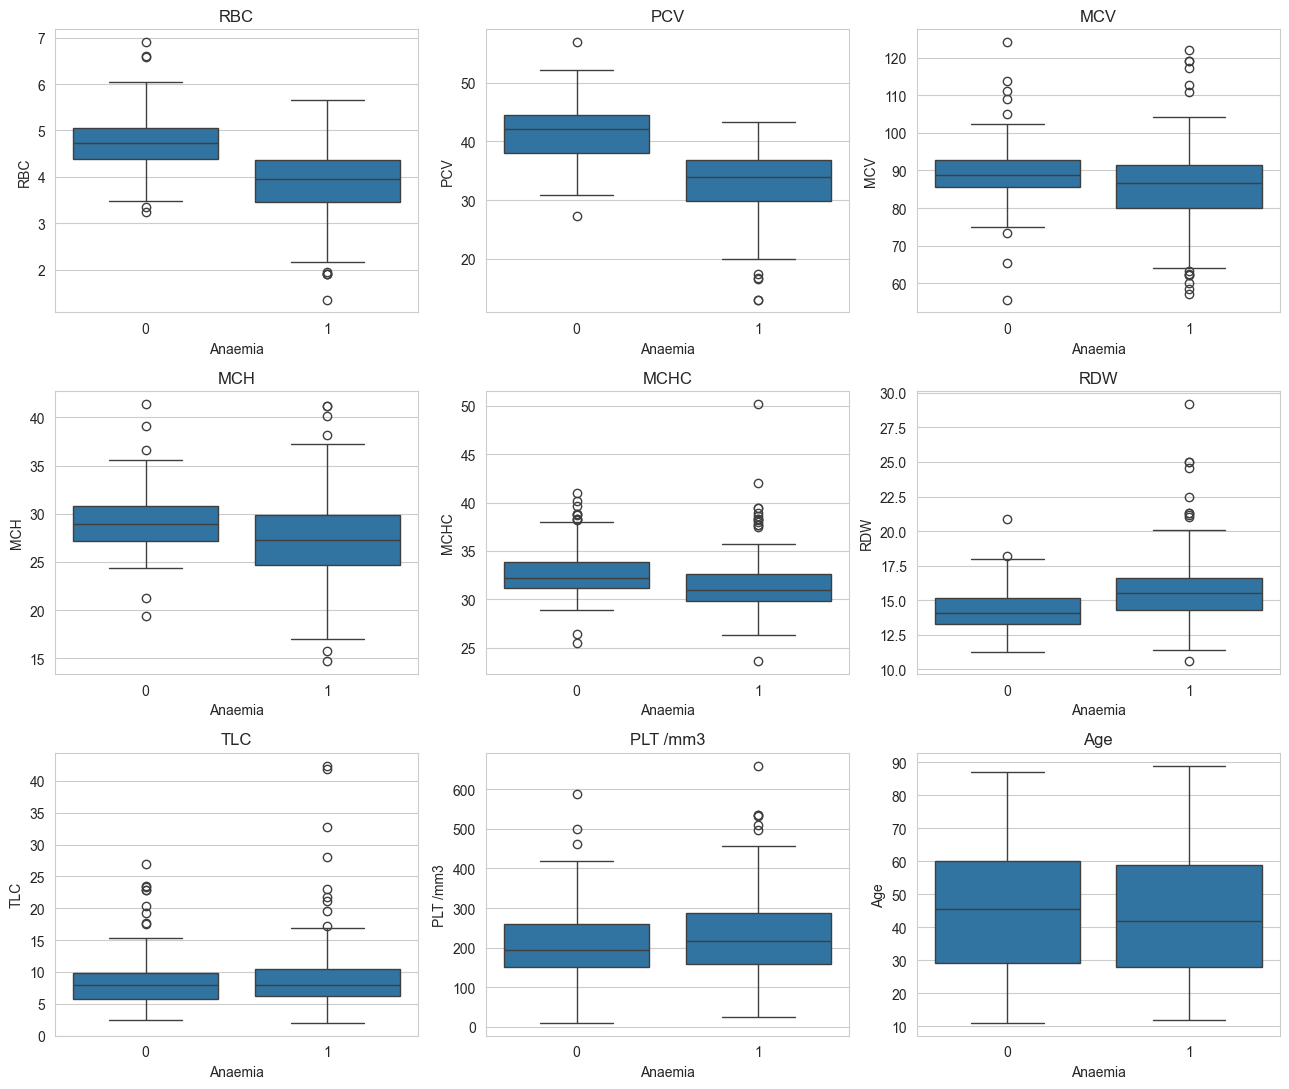

In [19]:
features_plot = ['RBC','PCV','MCV','MCH','MCHC','RDW','TLC','PLT /mm3','Age']
fig, axes = plt.subplots(3,3, figsize=(13,11))
for ax, col in zip(axes.flatten(), features_plot):
    sns.boxplot(data=df, x='Anaemia', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
plt.close()

In [20]:
X = df.drop(columns=['HGB','Anaemia'])
y = df['Anaemia']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
 
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (291, 10) Test shape: (73, 10)


In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

In [24]:
results = []
roc_data = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [26]:
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:,1] if hasattr(model, "predict_proba") else None
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    cv_acc = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy').mean()
    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'ROC-AUC': auc, 'CV-Accuracy(5fold)': cv_acc
    })
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_data[name] = (fpr, tpr, auc)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Non-Anaemic','Anaemic']))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
 


=== Logistic Regression ===
              precision    recall  f1-score   support

 Non-Anaemic       0.94      0.91      0.92        33
     Anaemic       0.93      0.95      0.94        40

    accuracy                           0.93        73
   macro avg       0.93      0.93      0.93        73
weighted avg       0.93      0.93      0.93        73

Confusion Matrix:
 [[30  3]
 [ 2 38]]

=== Decision Tree ===
              precision    recall  f1-score   support

 Non-Anaemic       0.90      0.82      0.86        33
     Anaemic       0.86      0.93      0.89        40

    accuracy                           0.88        73
   macro avg       0.88      0.87      0.87        73
weighted avg       0.88      0.88      0.88        73

Confusion Matrix:
 [[27  6]
 [ 3 37]]

=== Random Forest ===
              precision    recall  f1-score   support

 Non-Anaemic       0.94      0.91      0.92        33
     Anaemic       0.93      0.95      0.94        40

    accuracy                   

In [27]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)

In [29]:
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall       F1  ROC-AUC  CV-Accuracy(5fold)
Logistic Regression  0.931507   0.926829   0.950 0.938272 0.965152            0.951841
      Random Forest  0.931507   0.926829   0.950 0.938272 0.967045            0.934600
  Gradient Boosting  0.890411   0.880952   0.925 0.902439 0.971970            0.924430
      Decision Tree  0.876712   0.860465   0.925 0.891566 0.871591            0.897019
        Naive Bayes  0.835616   0.791667   0.950 0.863636 0.915909            0.872881
                SVM  0.835616   0.833333   0.875 0.853659 0.943939            0.924430
                KNN  0.808219   0.795455   0.875 0.833333 0.882955            0.849036


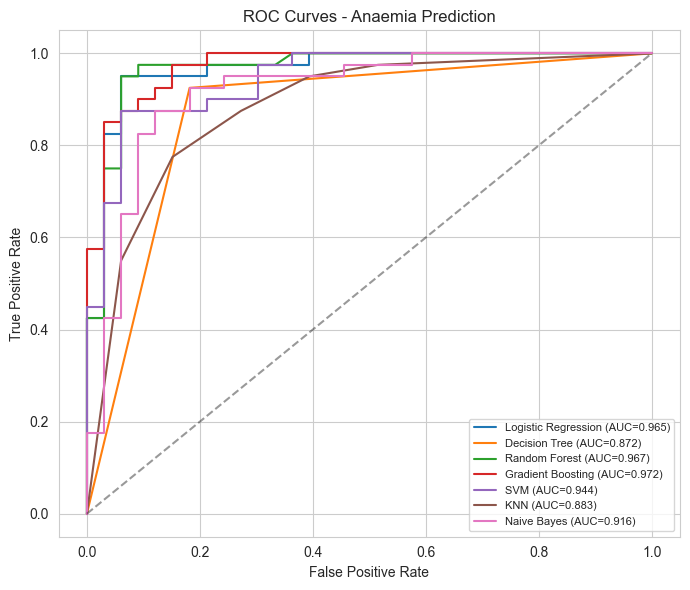

In [30]:
plt.figure(figsize=(7,6))
for name,(fpr,tpr,auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Anaemia Prediction')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

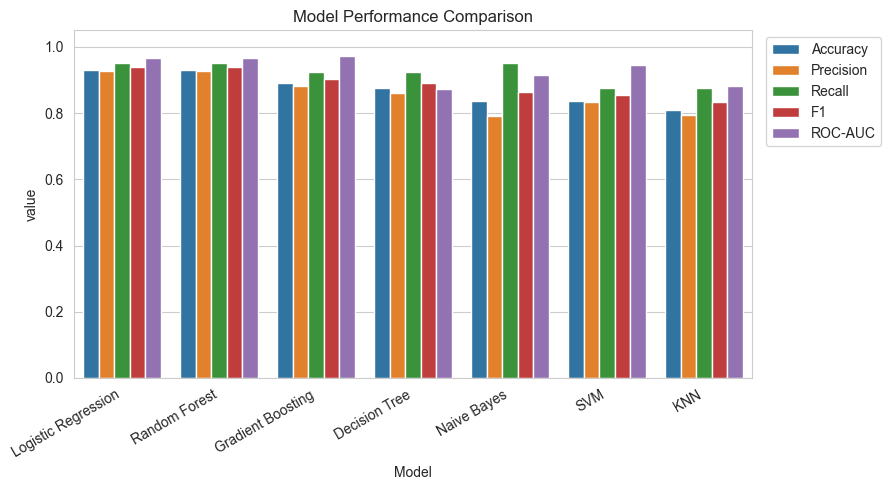

In [31]:
plt.figure(figsize=(9,5))
melted = results_df.melt(id_vars='Model', value_vars=['Accuracy','Precision','Recall','F1','ROC-AUC'])
sns.barplot(data=melted, x='Model', y='value', hue='variable')
plt.xticks(rotation=30, ha='right')
plt.ylim(0,1.05)
plt.title('Model Performance Comparison')
plt.legend(bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()
plt.close()
 

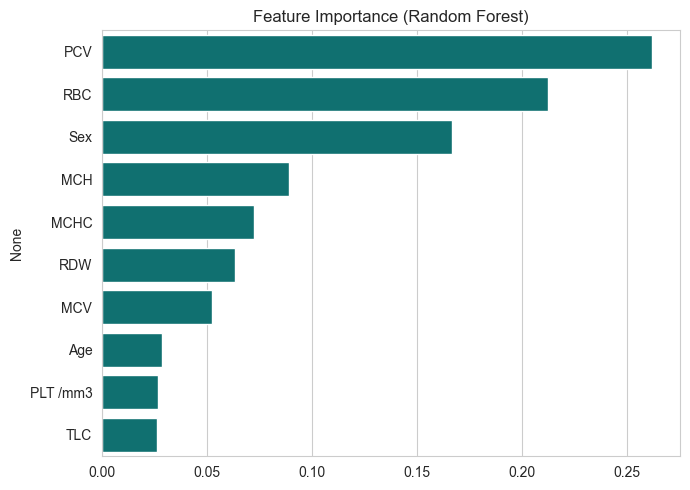


Feature Importances:
 PCV         0.262099
RBC         0.212344
Sex         0.166620
MCH         0.089120
MCHC        0.072515
RDW         0.063503
MCV         0.052321
Age         0.028611
PLT /mm3    0.026684
TLC         0.026183
dtype: float64


In [33]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, color='teal')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()
plt.close()
print("\nFeature Importances:\n", importances)

In [34]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
sample = X_test.head(10).copy()
sample_s = scaler.transform(sample)
sample['Actual'] = y_test.head(10).values
sample['Predicted'] = best_model.predict(sample_s)
sample['Pred_Proba_Anaemic'] = best_model.predict_proba(sample_s)[:,1].round(3)
print(f"\nBest Model: {best_model_name}")
print("\nSample Predictions:\n", sample.to_string(index=False))


Best Model: Logistic Regression

Sample Predictions:
  Age  Sex  RBC  PCV  MCV  MCH  MCHC   RDW   TLC  PLT /mm3  Actual  Predicted  Pred_Proba_Anaemic
74.0  0.0 4.13 40.2 97.3 30.5  31.3 15.30  8.54     276.0       0          0               0.096
55.0  1.0 4.22 34.3 81.2 26.5  32.6 16.66  5.90      35.0       1          1               0.985
65.0  1.0 3.17 27.9 88.0 28.4  32.3 13.90  9.55     166.0       1          1               1.000
35.0  1.0 4.53 37.3 82.3 23.8  29.0 16.90  8.85     348.0       1          1               0.997
57.0  1.0 4.29 31.5 73.4 27.7  37.7 13.60  5.70      80.0       1          1               0.902
62.0  0.0 3.34 27.4 81.9 32.3  39.4 13.60  6.90     105.0       1          1               0.701
89.0  1.0 2.99 23.1 77.3 23.1  29.9 18.30  6.40     187.0       1          1               1.000
71.0  0.0 2.83 25.0 88.5 34.4  38.9 15.90 13.00     280.0       1          1               0.969
52.0  0.0 4.54 43.5 95.8 29.7  31.0 14.70  8.68     214.0       0       